# Licensiameto

Nesse notebook, vamos explorar a ideia de tentar avaliar as condições dos ônibus que circulam pelo rio de janeiro. Usaramos o dataset licensiamento, que contem dados como a idade da frota e a presença de tecnologias como ar condicionado e elevador, e compararemos a qualidade de diferentes empresas e linhas, e avaliar a qualidade do serviço em cada bairro. A ideia final é fornecer as empresas e bairros com menor qualidade, o que serviria como base para fiscalizações.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("./licenciamento.csv")
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222625 entries, 0 to 222624
Data columns (total 28 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            222625 non-null  object 
 1   modo                            222625 non-null  object 
 2   id_veiculo                      222625 non-null  object 
 3   ano_fabricacao                  222625 non-null  int64  
 4   carroceria                      222625 non-null  object 
 5   data_ultima_vistoria            200112 non-null  object 
 6   id_carroceria                   222625 non-null  int64  
 7   id_chassi                       222625 non-null  int64  
 8   id_fabricante_chassi            222625 non-null  int64  
 9   id_interno_carroceria           222625 non-null  int64  
 10  id_planta                       222625 non-null  int64  
 11  indicador_ar_condicionado       222625 non-null  bool   
 12  indicador_elevad

## Verificando integridade dos dados

In [ ]:
Vamos primeiro verificar quais colunas contem nulos, e então averiguar a causa e o que fazer com esses nulos.

In [3]:
k = df.isna().sum() / len(df)
k = k[k>0]
print(k)

data_ultima_vistoria              0.101125
tecnologia                        0.280818
status                            0.139818
data_inicio_vinculo               0.396712
ano_ultima_vistoria_atualizado    0.250659
dtype: float64


### Coluna data da ultima vistoria

In [5]:
df['data_ultima_vistoria'] = pd.to_datetime(df['data_ultima_vistoria'])
print(df['data_ultima_vistoria'].head())

0   2022-06-29
1          NaT
2   2024-06-29
3   2024-02-26
4   2024-05-24
Name: data_ultima_vistoria, dtype: datetime64[ns]


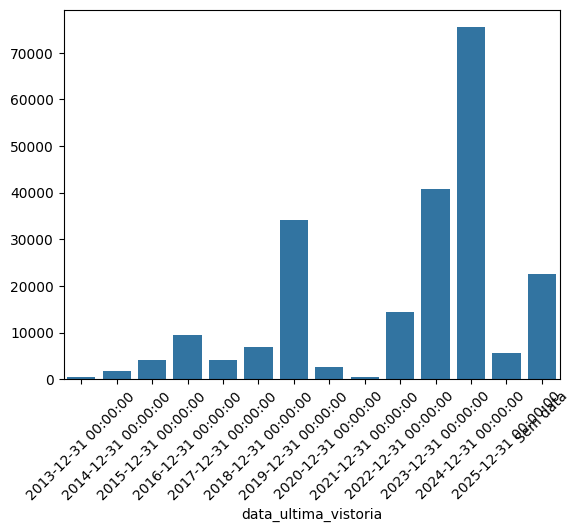

In [6]:
serie = df.groupby(pd.Grouper(key='data_ultima_vistoria', freq='YE')).size()
null_count = df['data_ultima_vistoria'].isna().sum()
serie.loc['Sem data'] = null_count
sns.barplot(serie)
plt.xticks(rotation=45)
plt.show()


<Axes: xlabel='ano_ultima_vistoria_atualizado'>

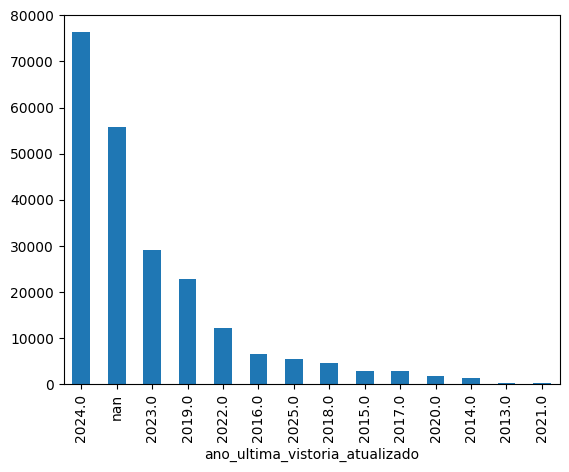

In [8]:
df["ano_ultima_vistoria_atualizado"].value_counts(dropna=False).plot(kind="bar")

O que vemos aqui é que a coluna de ano da ultima vistoria possui uma quantidade enorme de nulos, porém toda sua informação está compreendida dentro da coluna com a data completa, e por isso optamos por remvê-la. Ja a coluna de data também possui muitos nulos, e devemos investigar melhor sobre

### Coluna Tecnologia

<Axes: xlabel='tecnologia'>

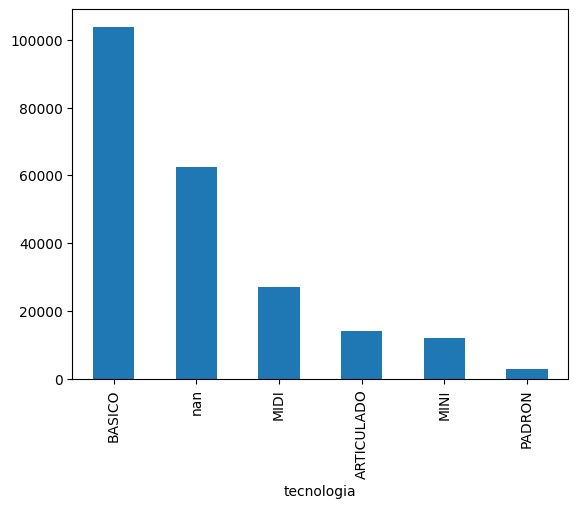

In [4]:
df["tecnologia"].value_counts(dropna=False).plot(kind="bar")

In [11]:
print(df['tipo_veiculo'].value_counts())

tipo_veiculo
51 ONIBUS BS URB C/AR C/E 2CAT    106223
45 BRT ARTICULADO                  17717
27 MINIONBUS URBAN C/AR C/ELEV     15466
31 ONBUS BASIC URB C/AR C/ELEV     13179
29 MIDIONBUS URBAN C/AR C/ELEV     10406
50 ONIBUS BS URB S/AR C/E 2CAT      9189
5 ONIBUS ROD. C/ AR                 8999
49 MIDI URB C/AR C/ELEV S/COBR      8945
48 MIDI URB S/AR C/ELEV S/COBR      8154
30 ONBUS BASIC URB S/AR C/ELEV      8091
28 MIDIONBUS URBAN S/AR C/ELEV      6571
61 RODOV. C/AR E ELEV               2997
44 BRT PADRON                       2559
53 MIDI URB C/AR C/ELEV 2 CATR      2327
42 ONIB PDRON URB P BAIXO C/AR      1166
26 MINIONBUS URBAN S/AR C/ELEV       570
52 MIDI URB S/AR C/ELEV 2 CATR        47
46 BRT BIARTICULADO                   17
43 ONIB PDRON URB P BAIXO S/AR         2
Name: count, dtype: int64


Verificamos aqui que toda informação contida em tecnologia está contida também em tipo_veiculo, que não tem nulos. portanto, optamos por descartar essa coluna.

## Coluna Licensiamento

<Axes: xlabel='status'>

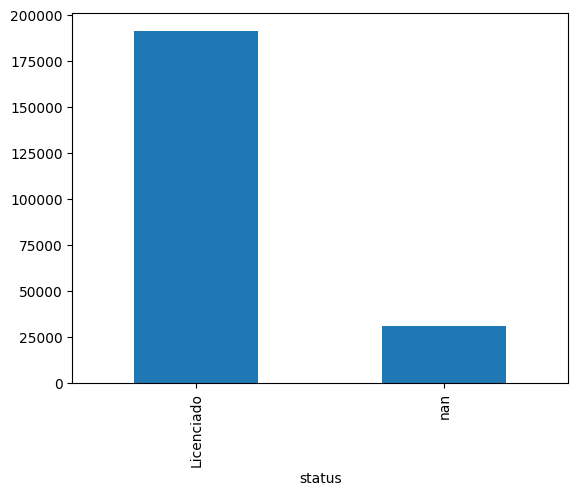

In [9]:
df["status"].value_counts(dropna=False).plot(kind="bar")

Os nan aqui aparentam ser os veiculos nãol licensiados. podemos substituir esses valores.

### Coluna data inicio vinculo

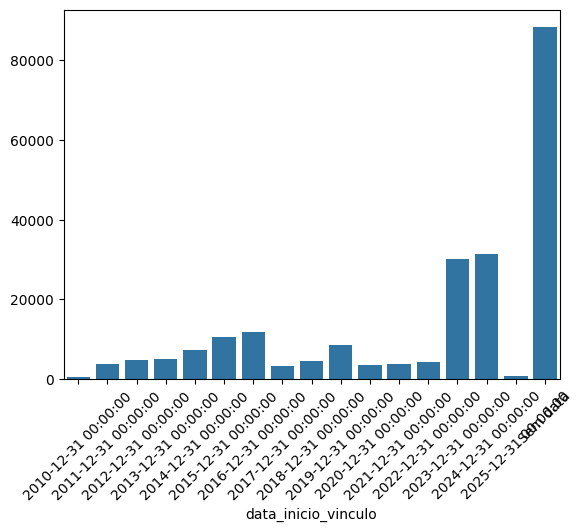

In [10]:
df['data_inicio_vinculo'] = pd.to_datetime(df['data_inicio_vinculo'])
serie = df.groupby(pd.Grouper(key='data_inicio_vinculo', freq='YE')).size()
null_count = df['data_inicio_vinculo'].isna().sum()
serie.loc['Sem data'] = null_count
sns.barplot(serie)
plt.xticks(rotation=45)
plt.show()

A quantidade de nulos presentes aqui é grande demais, inviabilizando o uso da coluna.

## Exploração e seleção de colunas

decidimos avaliar o conteúdo de cada uma das diversas colunas para determinar se a mantemos ou não no dataset.

id planta: talvez relacionar a planta do onibus com qualidade dele? ou os q circulam em cada linha 
permissao: nao sabemos oq significa
modo: todos iguais("onibus")
data: nao relevante, é a data da analise
ano_ultima_vistoria_atualizado: muitos nulos e informaçao disponivel em outra coluna
id_carroceria, id_interno_carroceria: ja temos o nome, valor numerio irrelevante
placa: pode ser util para dar join com outras tabelas
tipo_combustivel: era tudo diesel
tecnologia>

In [151]:
df_com_ar=df[df["indicador_ar_condicionado"] == True]
df_com_ar["tipo_veiculo"].value_counts()

tipo_veiculo
51 ONIBUS BS URB C/AR C/E 2CAT    106223
27 MINIONBUS URBAN C/AR C/ELEV     15466
31 ONBUS BASIC URB C/AR C/ELEV     13179
29 MIDIONBUS URBAN C/AR C/ELEV     10406
5 ONIBUS ROD. C/ AR                 8999
49 MIDI URB C/AR C/ELEV S/COBR      8945
61 RODOV. C/AR E ELEV               2997
53 MIDI URB C/AR C/ELEV 2 CATR      2327
42 ONIB PDRON URB P BAIXO C/AR      1166
Name: count, dtype: int64

In [152]:
df_sem_ar=df[df["indicador_ar_condicionado"] == False]
df_sem_ar["tipo_veiculo"].value_counts()

tipo_veiculo
45 BRT ARTICULADO                 17717
50 ONIBUS BS URB S/AR C/E 2CAT     9189
48 MIDI URB S/AR C/ELEV S/COBR     8154
30 ONBUS BASIC URB S/AR C/ELEV     8091
28 MIDIONBUS URBAN S/AR C/ELEV     6571
44 BRT PADRON                      2559
26 MINIONBUS URBAN S/AR C/ELEV      570
52 MIDI URB S/AR C/ELEV 2 CATR       47
46 BRT BIARTICULADO                  17
43 ONIB PDRON URB P BAIXO S/AR        2
Name: count, dtype: int64

O que obervamos aqui é que as colunas indicadoras de ar e elevador são feitas com base em um parsing na coluna tecnologia, verificando a presença de strings "c/ar" e "s/ar", por exemplo. não apenas isso gera resultados errados, como os brt sendo considerados como sem ar (o que é falso), esse dado é diferente do que imaginamos. Ele na realidade mostra apenas a presença teorica da tecnologia. Na prática, o que ocorre é que carros com a tecnologia de ar condicionado muitas vezes rodam com o equipamento desligado ou com defeito. Nosso objetivo era analisar justamente esse caso real, e por isso os dados não são úteis para nós. Dessa forma, a ideia inicial foi inviabilizada!

# Empresas

O dataset atualmente nao contém dados sobre empresas, porém os ids dos carros tem prefixos onde os tres primeiros digique indicam a empresa. Buscando o prefixo correspondente a cada empresa, criar nova coluna contendo o nome da empresa a qual cada veiculo pertence.

In [79]:
nums_ordem = df["id_veiculo"]

df["consorcio"] = nums_ordem.apply(lambda x: x[0])
df["empresa_cod"] = nums_ordem.apply(lambda x: x[1:4])

invalidos = df[~df['empresa_cod'].str.match(r'^\d{3}$', na=False)]

print(invalidos[["id_veiculo", "empresa_cod"]])

       id_veiculo empresa_cod
25774     M9I2066         9I2
47655     M9I2066         9I2
53296     M9I2066         9I2
65374     M9I2066         9I2
75165     M9I2066         9I2
78232     M9I2066         9I2
95082     M9I2066         9I2
107772    M9I2066         9I2
111002    M9I2066         9I2
112137    M9I2066         9I2
115199    M9I2066         9I2
120411    M9I2066         9I2
128866    M9I2066         9I2
134430    M9I2066         9I2
135886    M9I2066         9I2
140353    M9I2066         9I2
143693    M9I2066         9I2
146210    M9I2066         9I2
157228    M9I2066         9I2
157626    M9I2066         9I2
174614    M9I2066         9I2
178212    M9I2066         9I2
185479    M9I2066         9I2
202859    M9I2066         9I2
212753    M9I2066         9I2


In [80]:
print(df["consorcio"].unique())
consorcio_dict = {'A':"Intersul", "B":"Internorte", "C":"Transcarioca", "D":"Santa Cruz" , "E":"BRT", "M":"BRT"}
df["consorcio"] = df["consorcio"].map(consorcio_dict)
print(df["consorcio"].unique())

['B' 'D' 'C' 'A' 'M' 'E']
['Internorte' 'Santa Cruz' 'Transcarioca' 'Intersul' 'BRT']


In [81]:
#quero converter codigo de empresa pra numero, so q tem alguns errados!
invalidos = df[~df['empresa_cod'].str.match(r'^\d{3}$', na=False)]
print(invalidos[["id_veiculo", "empresa_cod"]])

       id_veiculo empresa_cod
25774     M9I2066         9I2
47655     M9I2066         9I2
53296     M9I2066         9I2
65374     M9I2066         9I2
75165     M9I2066         9I2
78232     M9I2066         9I2
95082     M9I2066         9I2
107772    M9I2066         9I2
111002    M9I2066         9I2
112137    M9I2066         9I2
115199    M9I2066         9I2
120411    M9I2066         9I2
128866    M9I2066         9I2
134430    M9I2066         9I2
135886    M9I2066         9I2
140353    M9I2066         9I2
143693    M9I2066         9I2
146210    M9I2066         9I2
157228    M9I2066         9I2
157626    M9I2066         9I2
174614    M9I2066         9I2
178212    M9I2066         9I2
185479    M9I2066         9I2
202859    M9I2066         9I2
212753    M9I2066         9I2


In [82]:
df.loc[25774]

data                                                            2024-05-08
modo                                                                ONIBUS
id_veiculo                                                         M9I2066
ano_fabricacao                                                        2023
carroceria                                                       MARCOPOLO
data_ultima_vistoria                                                   NaT
id_carroceria                                                           70
id_chassi                                                              285
id_fabricante_chassi                                                    32
id_interno_carroceria                                                   70
id_planta                                                             4058
indicador_ar_condicionado                                            False
indicador_elevador                                                    True
indicador_usb            

In [85]:
#esses errados são o brt. vou mudar eles pra ter codigo de empresa 100000, pra assim cair no lugar certo. e ai converto pra numerico
df['empresa_cod'] = df['empresa_cod'].replace('9I2', '100000')
df["empresa_cod"] = df["empresa_cod"].astype(int)

In [87]:
#agora crio nova coluna com o nome da empresa de cada veiculo
# fonte: https://viacircular.com.br/relacoes-de-frota/rj/
bins = pd.Series([0,10000,10500,11500,12000,12500,13000,17000,25500,27000,27500,28500,29000,30000,31000,32500,41000,42500,44500,47500,48000,50000,51500,53500,58000,63000,71000,71500,72000,86000,87000,99999])
bins /=100
labels = ["Transportes Paranapuan S/A", "Viação Penha Rio", "Viação Vila Real", "Expresso Recreio", "Viação Normandy do Triângulo Ltda", 
          "Transportes Barra Ltda", "Auto Viação Palmares Ltda", "Rodoviária Âncora Matias S/A", "Caprichosa Auto Ônibus Ltda", "Transportes Vila Isabel S/A ",
          "Viação Ideal S/A", "Empresa Braso Lisboa Ltda", "Transportes Futuro Ltda", "Viação VG Eireli ME","Viação Pavunense S/A", "Real Auto Ônibus Ltda ",
          "Viação Acari S/A", "Auto Viação Três Amigos Ltda", "Viação Redentor Ltda", "Auto Viação Alpha S/A", "Tijuquinha" ,"Viação Novacap S/A", 
          "Transportes Campo Grande Ltda", "Viação Nossa Senhora de Lourdes Ltda", "Gire Transportes Ltda", "Viação Verdun S/A", "Viação Nossa Senhora das Graças Ltda",
          "Transurb S/A", "Auto Viação Jabour Ltda", "Expresso Pégaso Ltda", "BRT Rio S.A."]
print(len(bins))
print(len(labels))

df["Empresa"] = pd.cut(df["empresa_cod"], bins=bins, labels=labels)
print(df["Empresa"].value_counts())

32
31
Empresa
BRT Rio S.A.                            18388
Auto Viação Alpha S/A                   17521
Auto Viação Palmares Ltda               14862
Viação VG Eireli ME                     13108
Expresso Pégaso Ltda                    12828
Real Auto Ônibus Ltda                   10297
Viação Redentor Ltda                    10214
Rodoviária Âncora Matias S/A             9614
Viação Acari S/A                         9130
Viação Novacap S/A                       7929
Transportes Vila Isabel S/A              7127
Viação Nossa Senhora de Lourdes Ltda     7007
Auto Viação Jabour Ltda                  5967
Transportes Campo Grande Ltda            5868
Empresa Braso Lisboa Ltda                5646
Viação Ideal S/A                         5540
Transportes Futuro Ltda                  5347
Viação Pavunense S/A                     5223
Caprichosa Auto Ônibus Ltda              5084
Viação Verdun S/A                        4804
Transurb S/A                             4610
Transportes Barra Lt

# Exploração por empresa

C:\Users\rhena\AppData\Local\Temp\ipykernel_17340\800490288.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot = df.groupby("Empresa")["ano_fabricacao"].agg("mean").reset_index()


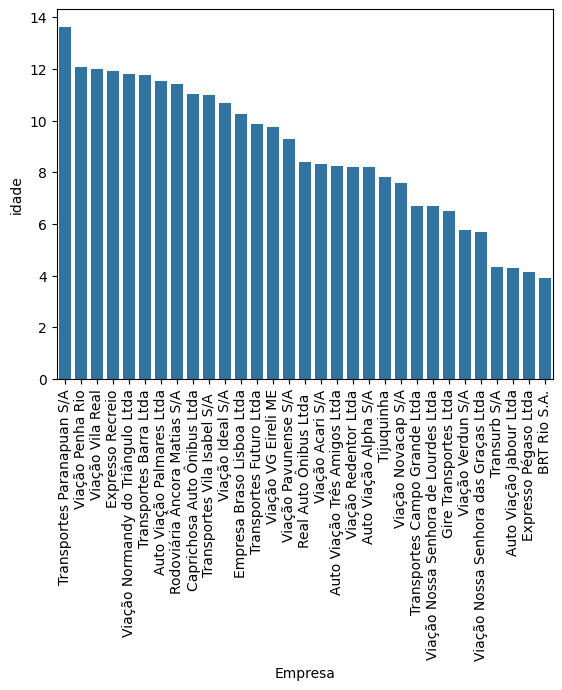

In [118]:
df["ano_fabricacao"] = df["ano_fabricacao"].astype(int)
plot = df.groupby("Empresa")["ano_fabricacao"].agg("mean").reset_index()
plot["idade"] =2026 -  plot["ano_fabricacao"]
plot["idade"] = sorted(plot["idade"], reverse=True)
sns.barplot(data=plot, x="Empresa",y="idade" )
plt.xticks(rotation=90)
plt.show()

In [123]:
df=  df.drop(columns = ['data', "modo","ano_ultima_vistoria_atualizado","id_carroceria","id_interno_carroceria","permissao","tipo_combustivel","tecnologia"  ])